In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("--- Part 1: Hyperparameter Tuning with Grid Search ---")

--- Part 1: Hyperparameter Tuning with Grid Search ---


In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names
target_names = data.target_names

print("\nDataset Features (X) shape:", X.shape)
print("Dataset Labels (y) shape:", y.shape)
print("Number of Features:", len(feature_names))
print("Target Names:", target_names)


Dataset Features (X) shape: (569, 30)
Dataset Labels (y) shape: (569,)
Number of Features: 30
Target Names: ['malignant' 'benign']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("\nTraining set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])



Training set size: 398
Test set size: 171


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures standardized.")



Features standardized.


In [5]:
model = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

print("\nHyperparameter grid defined:")

for param, values in param_grid.items():
    print(param, ":", values)


Hyperparameter grid defined:
n_estimators : [50, 100, 150]
max_depth : [None, 5, 10]
min_samples_split : [2, 5]


In [7]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)


print("\nStarting Grid Search with 5-Fold Cross-Validation...")

grid_search.fit(X_train_scaled, y_train)

print("\nGrid Search completed.")


Starting Grid Search with 5-Fold Cross-Validation...

Grid Search completed.


In [8]:
print("\nBest Hyperparameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(f"{grid_search.best_score_:.4f}")



Best Hyperparameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation Accuracy:
0.9725


In [9]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test, y_pred)

print("\nTest Set Accuracy:")
print(f"{test_accuracy:.4f}")


Test Set Accuracy:
0.9357


In [10]:
print("\n--- Classification Report ---")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_names
    )
)


--- Classification Report ---
              precision    recall  f1-score   support

   malignant       0.92      0.91      0.91        64
      benign       0.94      0.95      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171




--- Confusion Matrix ---


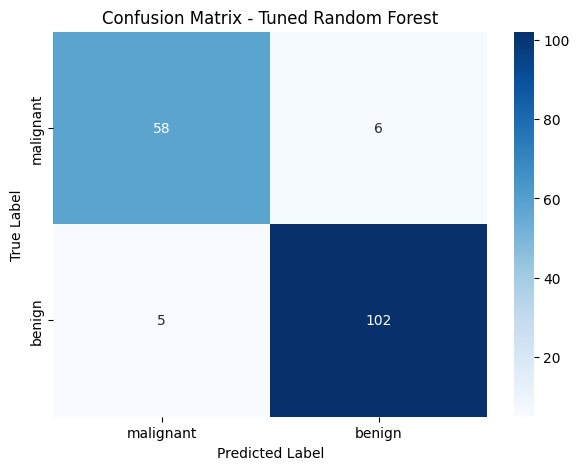

In [11]:
print("\n--- Confusion Matrix ---")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [12]:
results_df = pd.DataFrame(grid_search.cv_results_)

print("\n--- Top 5 Grid Search Results ---")

print(
    results_df[
        [
            'param_n_estimators',
            'param_max_depth',
            'param_min_samples_split',
            'mean_test_score',
            'rank_test_score'
        ]
    ]
    .sort_values(by='rank_test_score')
    .head()
)


--- Top 5 Grid Search Results ---
    param_n_estimators param_max_depth  param_min_samples_split  \
1                  100            None                        2   
7                  100               5                        2   
11                 150               5                        5   
8                  150               5                        2   
13                 100              10                        2   

    mean_test_score  rank_test_score  
1          0.972500                1  
7          0.972500                1  
11         0.972500                1  
8          0.972500                1  
13         0.969968                5  


In [13]:
print("\n--- Part 2: K-Fold Cross-Validation ---")

# 1. Create Random Forest Model
model_cv = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


--- Part 2: K-Fold Cross-Validation ---


In [15]:
k_folds = 5

kf = KFold(
    n_splits=k_folds,
    shuffle=True,
    random_state=42
)
print("\nPerforming 5-Fold Cross-Validation...")



Performing 5-Fold Cross-Validation...


In [16]:
cv_scores = cross_val_score(
    model_cv,
    X_train_scaled,
    y_train,
    cv=kf,
    scoring='accuracy'
)

print("\nCross-Validation Scores:")

for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")



Cross-Validation Scores:
Fold 1: 0.9500
Fold 2: 1.0000
Fold 3: 0.9375
Fold 4: 0.9620
Fold 5: 0.9367


In [17]:
mean_accuracy = np.mean(cv_scores)
std_accuracy = np.std(cv_scores)

print("\nMean Cross-Validation Accuracy:")
print(f"{mean_accuracy:.4f}")

print("\nStandard Deviation:")
print(f"{std_accuracy:.4f}")



Mean Cross-Validation Accuracy:
0.9572

Standard Deviation:
0.0233


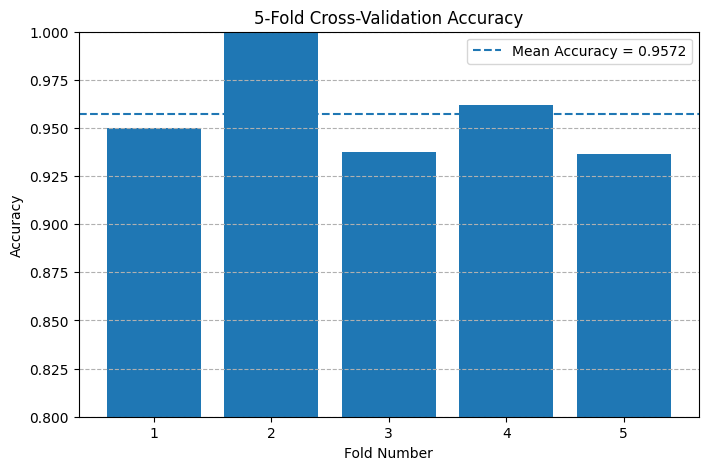

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    range(1, k_folds + 1),
    cv_scores
)

plt.axhline(
    y=mean_accuracy,
    linestyle='--',
    label=f'Mean Accuracy = {mean_accuracy:.4f}'
)

plt.title("5-Fold Cross-Validation Accuracy")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--')

plt.show()


In [19]:
print("\n--- Why is Cross-Validation Important? ---")

print("1. Provides a more reliable estimate of model performance.")
print("2. Helps reduce overfitting.")
print("3. Uses different portions of the dataset for training and validation.")
print("4. Helps measure the stability of the model.")


--- Why is Cross-Validation Important? ---
1. Provides a more reliable estimate of model performance.
2. Helps reduce overfitting.
3. Uses different portions of the dataset for training and validation.
4. Helps measure the stability of the model.
